<a href="https://colab.research.google.com/github/vhemavenkat4-bit/gitsql1/blob/main/MOVIE_RATING_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
print("Shape:", df.shape)

print("Columns:")
print(df.columns)

print("Dataset Information:")
df.info()

Shape: (15509, 10)
Columns:
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [4]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [5]:
# Remove rows where Rating is missing
df = df.dropna(subset=['Rating'])

print(df.shape)

(7919, 10)


In [7]:
# Fill missing categorical values
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')

# Fill Year with the most frequent value
df['Year'] = df['Year'].fillna(df['Year'].mode()[0])

# Convert Duration to numeric
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

# Clean Votes column
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

In [10]:
df.isnull().sum()

,0
Name,0
Year,0
Duration,0
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


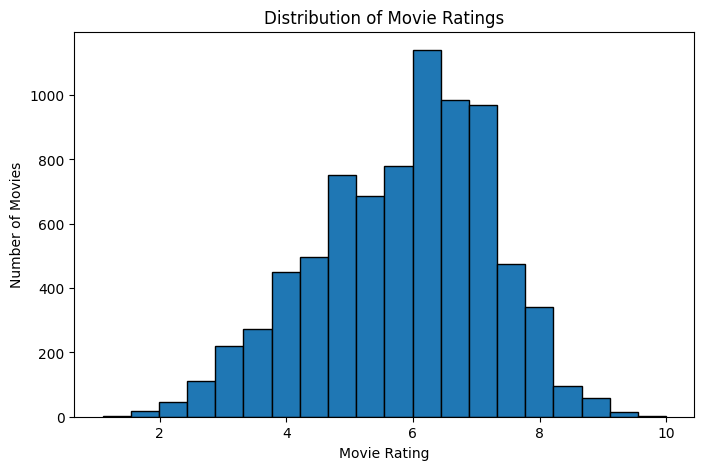

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Rating'], bins=20, edgecolor='black')

plt.title("Distribution of Movie Ratings")
plt.xlabel("Movie Rating")
plt.ylabel("Number of Movies")

plt.show()

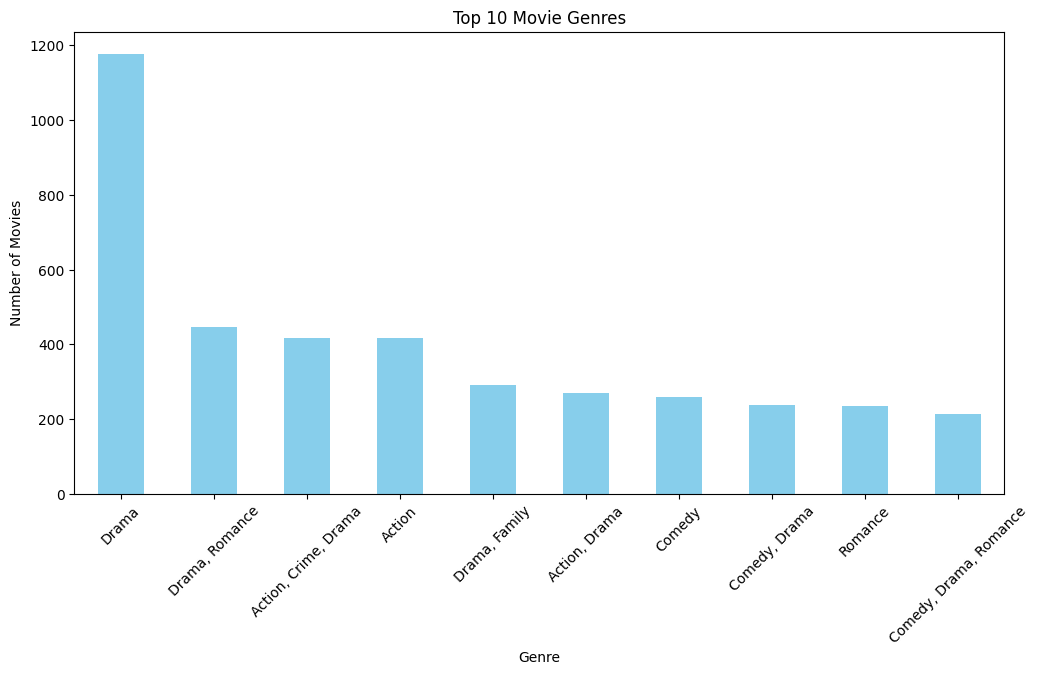

In [12]:
import matplotlib.pyplot as plt

top_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_genres.plot(kind='bar', color='skyblue')

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor 1'] = le.fit_transform(df['Actor 1'])
df['Actor 2'] = le.fit_transform(df['Actor 2'])
df['Actor 3'] = le.fit_transform(df['Actor 3'])

In [14]:
X = df.drop(['Rating','Name'], axis=1)

y = df['Rating']

print(X.head())

     Year  Duration  Genre  Votes  Director  Actor 1  Actor 2  Actor 3
1  (2019)     109.0    268      8       811     1782     2815      377
3  (2019)     110.0    207     35      1749     1589      890     2572
5  (1997)     147.0    177    827      2005      508       85     2449
6  (2005)     142.0    331   1086      2643      931     1388     3030
8  (2012)      82.0    367    326       174     2521     1461     1205


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

ValueError: could not convert string to float: '(2019)'

In [17]:

print(X.dtypes)

Year         object
Duration    float64
Genre         int64
Votes         int64
Director      int64
Actor 1       int64
Actor 2       int64
Actor 3       int64
dtype: object


In [18]:
# Extract only the 4-digit year
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')

# Convert to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Fill missing values with median
df['Year'] = df['Year'].fillna(df['Year'].median())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7943/3488126797.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')


In [19]:
X = df.drop(['Name', 'Rating'], axis=1)
y = df['Rating']

In [20]:
print(X.dtypes)

Year          int64
Duration    float64
Genre         int64
Votes         int64
Director      int64
Actor 1       int64
Actor 2       int64
Actor 3       int64
dtype: object


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

✅ Model Trained Successfully!


In [22]:
print(X.isnull().sum())

Year        0
Duration    0
Genre       0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


In [23]:
print(X.head())

   Year  Duration  Genre  Votes  Director  Actor 1  Actor 2  Actor 3
1  2019     109.0    268      8       811     1782     2815      377
3  2019     110.0    207     35      1749     1589      890     2572
5  1997     147.0    177    827      2005      508       85     2449
6  2005     142.0    331   1086      2643      931     1388     3030
8  2012      82.0    367    326       174     2521     1461     1205


In [24]:
predictions = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", round(mae,3))
print("Root Mean Squared Error (RMSE):", round(rmse,3))
print("R² Score:", round(r2,3))

Mean Absolute Error (MAE): 0.835
Root Mean Squared Error (RMSE): 1.104
R² Score: 0.345


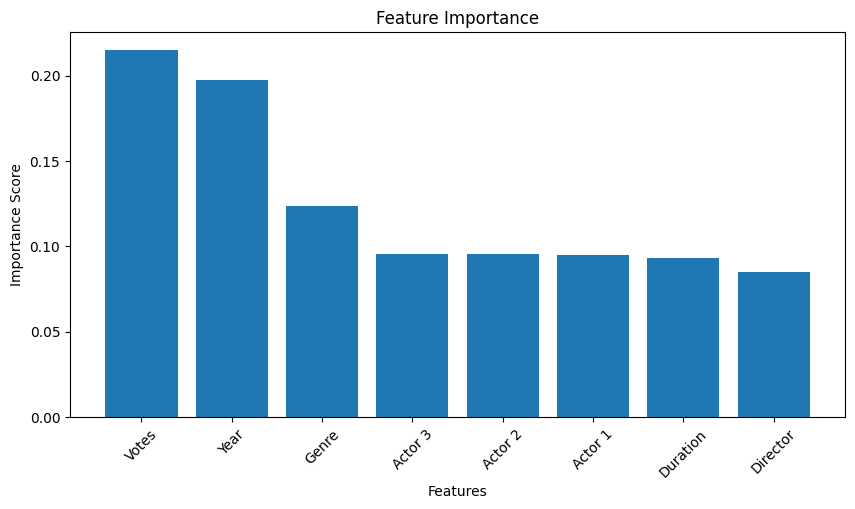

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

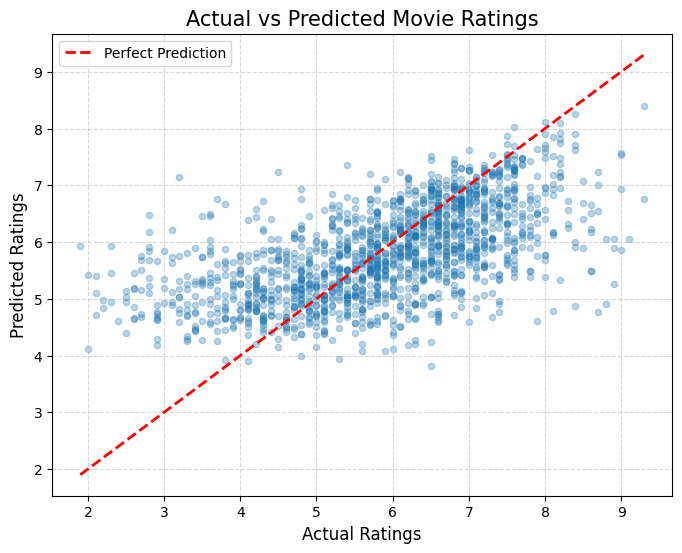

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.3,      # More transparent points
    s=20            # Smaller points
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.title("Actual vs Predicted Movie Ratings", fontsize=15)
plt.xlabel("Actual Ratings", fontsize=12)
plt.ylabel("Predicted Ratings", fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()